<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-02-28 10:25:38--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv.1’

survey-data.csv.1   100%[===================>] 152.13M  37.8MB/s    in 4.0s    

2026-02-28 10:25:45 (38.4 MB/s) - ‘survey-data.csv.1’ saved [159525875/159525875]



**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [2]:
!pip install pandas 
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [3]:
# Read the CSV file
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [4]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
conn.close()


**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [5]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [6]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


,COUNT(*)
0,65437


## Demo: Listing All Tables


To view the names of all tables in the database:


In [7]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [9]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


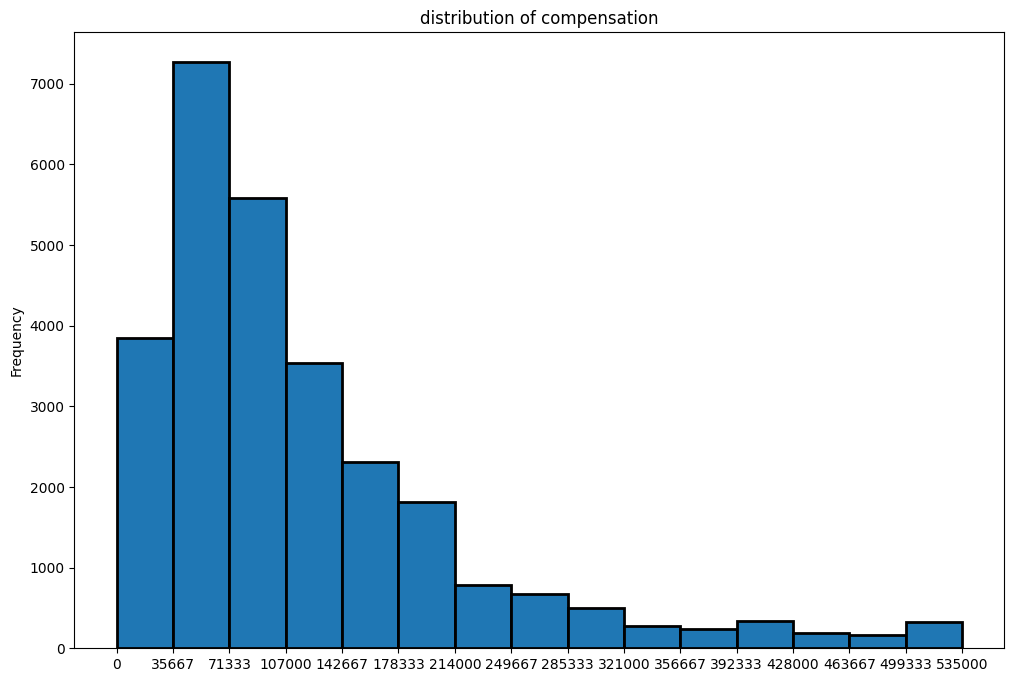

In [10]:
## Write your code here

CompTotal=pd.read_sql_query('Select CompTotal from main where CompTotal>0', conn)

Q1=np.quantile(CompTotal['CompTotal'], 0.25)
Q3=np.quantile(CompTotal['CompTotal'], 0.75)
IQR=Q3-Q1


cleanCompTotal=pd.read_sql_query(f'Select CompTotal from main where CompTotal between {Q1-1.5*IQR} and {Q3+1.5*IQR}', conn) # Extreme compensation values were removed using the IQR method to improve the readability of the histogram and prevent the distribution from being dominated by extreme outliers.
                                                                                                                            # More about Compensation data in DataWrangling/09_ImputMissing_Values
entries_in_bin, bin_range=np.histogram(cleanCompTotal['CompTotal'],15)

cleanCompTotal['CompTotal'].plot(kind='hist', figsize=(12,8), xticks=bin_range, bins=15, linewidth=2, edgecolor='black')
plt.title('distribution of compensation')
plt.show()

**Box Plots**

Plot a box plot of Age.


(65115, 1)


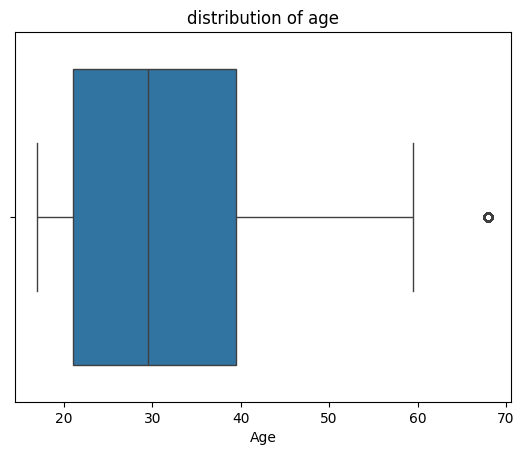

In [11]:
## Write your code here

age=pd.read_sql_query('Select Age from main where Age <> "Prefer not to say"', conn)  # Deleting this value to convert this column from object type to float

print(age.shape)


age['Age']=age['Age'].replace({
    'Under 18 years old':17
    ,'18-24 years old':21
    ,'25-34 years old':29.5
    ,'35-44 years old':39.5
    ,'45-54 years old':49.5
    ,'55-64 years old':59.5
    ,'65 years or older':68
})

age['Age']=pd.to_numeric(age['Age'],errors='coerce')
age = age.dropna(subset=['Age'])

sns.boxplot( x=age['Age'])
plt.xlabel('Age')
plt.title('distribution of age')
plt.show()



### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


(29611, 2)


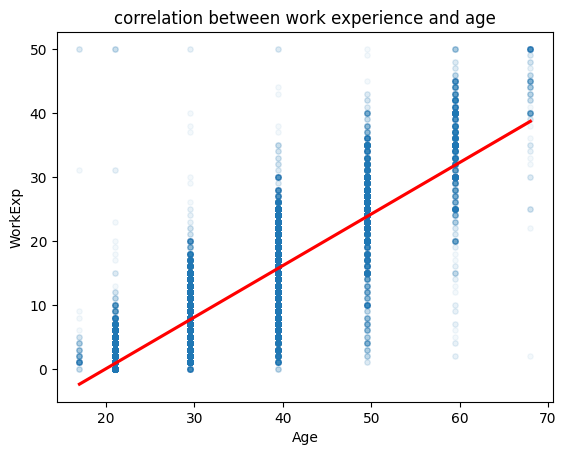

In [12]:
## Write your code here

age_exp_df=pd.read_sql_query(
    '''Select Age, WorkExp from main 
    where Age is not null
    and WorkExp is not null
    and Age <> "Prefer not to say" 
    and WorkExp >= 0''', conn) # Null values were dropped because only full records are useful to measure correlation

print(age_exp_df.shape)


age_exp_df['Age']=age_exp_df['Age'].replace({   # Convert age categories into numeric midpoints to allow correlation analysis
    'Under 18 years old':17
    ,'18-24 years old':21
    ,'25-34 years old':29.5
    ,'35-44 years old':39.5
    ,'45-54 years old':49.5
    ,'55-64 years old':59.5
    ,'65 years or older':68
})

age_exp_df['Age']=pd.to_numeric(age_exp_df['Age'], errors='coerce')
age_exp_df = age_exp_df.dropna(subset=['Age', 'WorkExp'])

sns.regplot(age_exp_df, x='Age', y='WorkExp', line_kws={'color':'red'}, scatter_kws={'s':15, 'alpha':0.05})
plt.title('correlation between work experience and age')
plt.show()


The visualization should be improved by removing outliers. There are clear inconsistencies in the data, such as people under 30 reporting over 30 years of work experience

**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


In [13]:
## Write your code here

df=pd.read_sql_query('''Select Frustration, TimeSearching, Age from main 
                    where Frustration is not null
                    and TimeSearching is not null
                    and Age <> "Prefer not to say"''', conn)

print('Frustration unique values \n\n',df['Frustration'].unique())
print('\n\n\n TimeSearching unique values \n\n',df['TimeSearching'].unique())
print('\n\n\n Age unique values \n\n',df['Age'].unique())
print('\n\n\n TimeSearching value counts',df['TimeSearching'].value_counts())

Frustration unique values 

 <StringArray>
[                                                                                                                                                            'Amount of technical debt;Number of software tools in use;Tracking my work;Showing my contributions',
                                                                                                                                                                                               'Amount of technical debt;Complexity of tech stack for deployment',
                                                                                                                'Amount of technical debt;Complexity of tech stack for deployment;Complexity of tech stack for build;Maintaining security of code being produced',
                                                'Amount of technical debt;Tracking my work;Complexity of tech stack for build;Patching/updating core components;Maintaining security

In [14]:

df['Frustration']=df['Frustration'].str.split(';')
df=df.explode('Frustration')                                     # Frustration is a multi-select question; split and explode allow analyzing each selected frustration type separately

In [15]:

df['Age']=df['Age'].replace({
    'Under 18 years old':17
    ,'18-24 years old':21
    ,'25-34 years old':29.5
    ,'35-44 years old':39.5
    ,'45-54 years old':49.5
    ,'55-64 years old':59.5
    ,'65 years or older':68
})

df['Age']=pd.to_numeric(df['Age'], errors='coerce')

df['TimeSearching']=df['TimeSearching'].replace({
    'Less than 15 minutes a day':7.5
    ,'15-30 minutes a day':22.5
    ,'30-60 minutes a day':45
    ,'60-120 minutes a day':90
    ,'Over 120 minutes a day':165
})

print(df.shape)
df['TimeSearching']=pd.to_numeric(df['TimeSearching'], errors='coerce')
df = df.dropna(subset=['Age', 'TimeSearching', 'Frustration'])
df.head(10)


(83115, 3)


,Frustration,TimeSearching,Age
0,Amount of technical debt,45.0,39.5
0,Number of software tools in use,45.0,39.5
0,Tracking my work,45.0,39.5
0,Showing my contributions,45.0,39.5
1,Amount of technical debt,45.0,39.5
1,Complexity of tech stack for deployment,45.0,39.5
2,Amount of technical debt,90.0,49.5
2,Complexity of tech stack for deployment,90.0,49.5
2,Complexity of tech stack for build,90.0,49.5
2,Maintaining security of code being produced,90.0,49.5


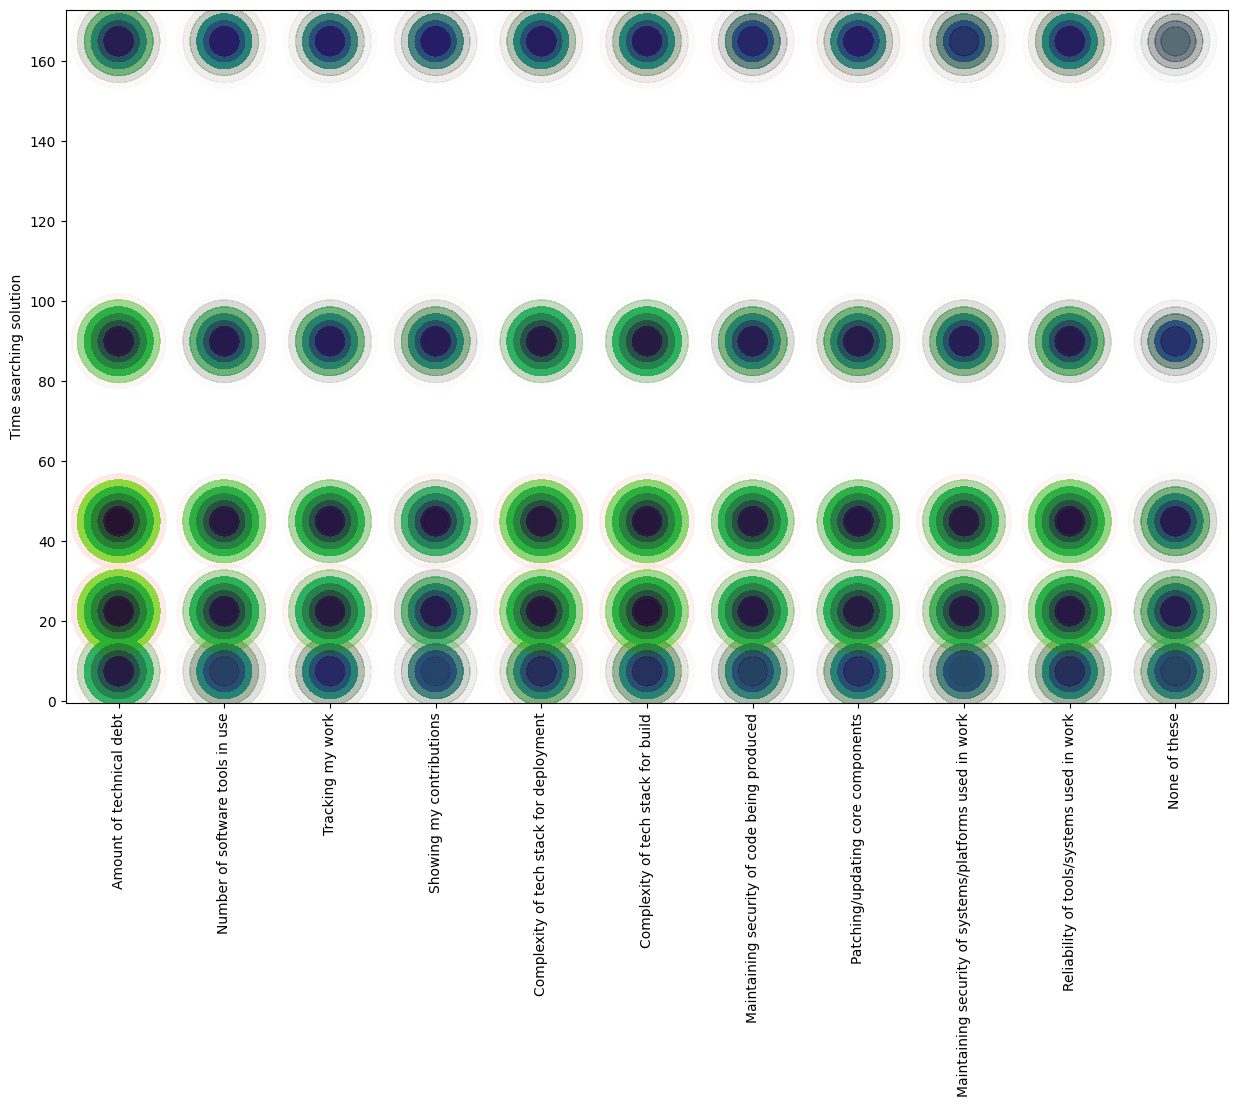

In [16]:
plt.figure(figsize=(15,9))
plt.scatter(x=df['Frustration'], y=df['TimeSearching'], alpha=0.005, s=df['Age']**2, c=df['Age'])
plt.xticks(rotation=90)
plt.ylabel('Time searching solution')
plt.show()

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


In [17]:
## Write your code here
data_bases=pd.read_sql_query(
    ''' Select DatabaseWantToWorkWith 
        from main
        where DatabaseWantToWorkWith is not null''', conn
)

print('number of records', len(data_bases['DatabaseWantToWorkWith']))
data_bases.head(10)

number of records 42558


,DatabaseWantToWorkWith
0,PostgreSQL
1,Firebase Realtime Database
2,MongoDB;MySQL;PostgreSQL
3,PostgreSQL;SQLite
4,Cloud Firestore
5,Supabase
6,MongoDB;MySQL;PostgreSQL;Redis
7,Elasticsearch;MongoDB;PostgreSQL;SQLite
8,Microsoft SQL Server;PostgreSQL;SQLite
9,MySQL


In [18]:
data_bases['DatabaseWantToWorkWith']=data_bases['DatabaseWantToWorkWith'].str.split(';')
bases_counted=data_bases.explode('DatabaseWantToWorkWith').value_counts()               # DatabaseWantToWorkWith is a multi-select question, split and explode allow analyzing each selected database type separately
bases_counted.iloc[0:5]

DatabaseWantToWorkWith
PostgreSQL                24005
SQLite                    13489
MySQL                     12269
MongoDB                   10982
Redis                     10847
Name: count, dtype: int64

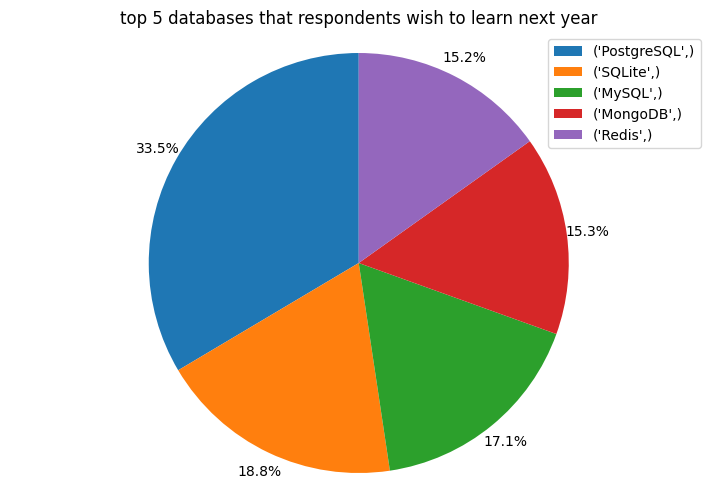

In [19]:
bases_counted.iloc[0:5].plot(kind='pie'
                              ,figsize=(9,6)
                              ,autopct='%1.1f%%'
                              ,startangle=90
                              ,labels=None
                              ,pctdistance=1.1,)
plt.title('top 5 databases that respondents wish to learn next year')
plt.legend(labels=bases_counted.iloc[0:5].index)
plt.axis('equal')
plt.show()

**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 25 to 44.


In [20]:
## Write your code here

Times=pd.read_sql_query(
    '''select Age, TimeSearching, TimeAnswering
    from main
    where TimeSearching is not null
    and TimeAnswering is not null
    and Age in("25-34 years old","35-44 years old")''', conn)

print('unique values of Time Searching\n\n',Times['TimeSearching'].unique())
print('\n\n\nunique values of Time Answearing\n\n',Times['TimeAnswering'].unique())
Times.head(10)

unique values of Time Searching

 <StringArray>
[       '30-60 minutes a day',        '15-30 minutes a day',
 'Less than 15 minutes a day',       '60-120 minutes a day',
     'Over 120 minutes a day']
Length: 5, dtype: str



unique values of Time Answearing

 <StringArray>
[      '60-120 minutes a day',        '15-30 minutes a day',
        '30-60 minutes a day', 'Less than 15 minutes a day',
     'Over 120 minutes a day']
Length: 5, dtype: str


,Age,TimeSearching,TimeAnswering
0,35-44 years old,30-60 minutes a day,60-120 minutes a day
1,35-44 years old,30-60 minutes a day,15-30 minutes a day
2,25-34 years old,15-30 minutes a day,30-60 minutes a day
3,25-34 years old,Less than 15 minutes a day,15-30 minutes a day
4,35-44 years old,15-30 minutes a day,Less than 15 minutes a day
5,35-44 years old,30-60 minutes a day,30-60 minutes a day
6,25-34 years old,60-120 minutes a day,15-30 minutes a day
7,25-34 years old,60-120 minutes a day,15-30 minutes a day
8,35-44 years old,60-120 minutes a day,60-120 minutes a day
9,25-34 years old,30-60 minutes a day,15-30 minutes a day


In [21]:
Times['TimeSearching']=Times['TimeSearching'].replace({
    'Less than 15 minutes a day':7.5
    ,'15-30 minutes a day':22.5
    ,'30-60 minutes a day':45
    ,'60-120 minutes a day':90
    ,'Over 120 minutes a day':165
})

Times['TimeAnswering']=Times['TimeAnswering'].replace({
    'Less than 15 minutes a day':7.5
    ,'15-30 minutes a day':22.5
    ,'30-60 minutes a day':45
    ,'60-120 minutes a day':90
    ,'Over 120 minutes a day':165
})

Times['TimeSearching']=pd.to_numeric(Times['TimeSearching'], errors='coerce')
Times['TimeAnswering']=pd.to_numeric(Times['TimeAnswering'], errors='coerce')
Times=Times.dropna(axis=0)

times_median=Times.groupby('Age').median()
times_median

,TimeSearching,TimeAnswering
Age,,
25-34 years old,45.0,22.5
35-44 years old,45.0,45.0


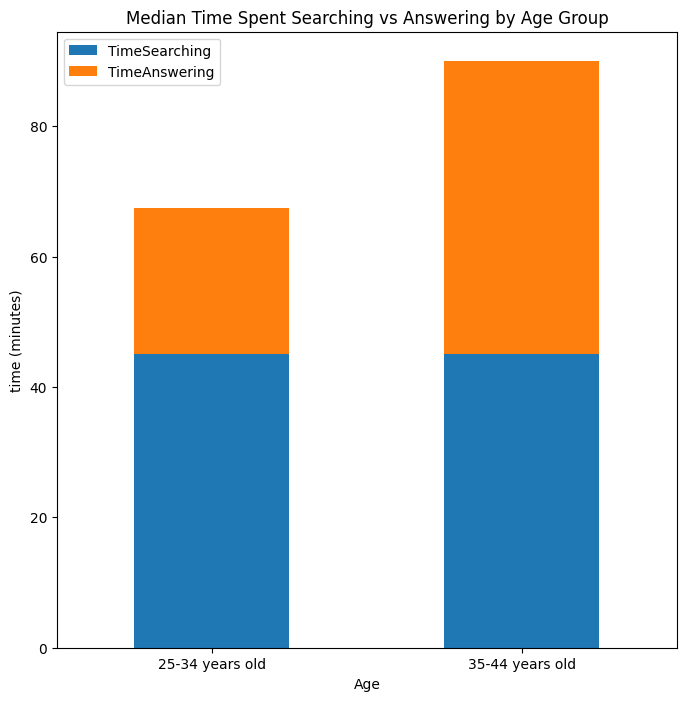

In [22]:
times_median.plot(kind='bar', stacked=True, figsize=(8,8))
plt.title('Median Time Spent Searching vs Answering by Age Group')
plt.ylabel("time (minutes)")
plt.xticks(rotation=0)
plt.legend()
plt.show()

### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 64.


In [23]:
## Write your code here

age_comp=pd.read_sql_query(
    f''' Select Age, CompTotal
    from main 
    where Age in ("45-54 years old", "55-64 years old")
    and CompTotal between {Q1-1.5*IQR} and {Q3+1.5*IQR}''', conn)  # Remove outliers using IQR method calculated on the full compensation distribution


print('table shape', age_comp.shape)
median_comp=age_comp.groupby('Age').median()
median_comp.head()

table shape (4168, 2)


,CompTotal
Age,
45-54 years old,115000.0
55-64 years old,124110.0


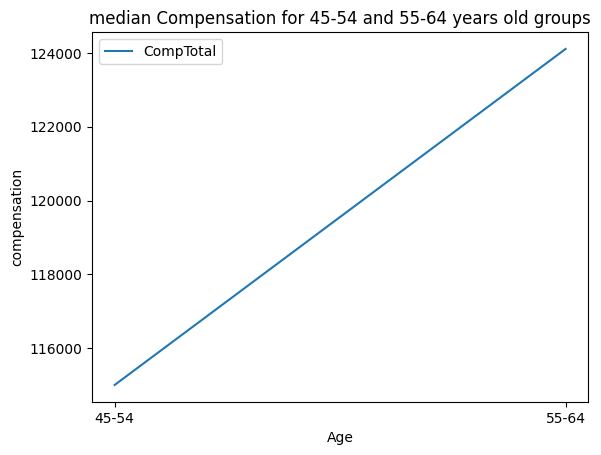

In [24]:
median_comp.plot(kind='line', title='median Compensation for 45-54 and 55-64 years old groups', ylabel='compensation')
plt.xticks(np.arange(0,2,1),['45-54','55-64'])
plt.show()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


In [25]:
## Write your code here

branch_sat=pd.read_sql_query(
    '''Select MainBranch ,JobSat
    from main
    where JobSat>=0''', conn)

print('summaraized data\n\n',branch_sat['MainBranch'].value_counts())
median_sat=branch_sat.groupby('MainBranch').median()
median_sat

summaraized data

 MainBranch
I am a developer by profession                                                           26627
I am not primarily a developer, but I write code sometimes as part of my work/studies     1851
I used to be a developer by profession, but no longer am                                   403
I am learning to code                                                                      138
I code primarily as a hobby                                                                107
Name: count, dtype: int64


,JobSat
MainBranch,
I am a developer by profession,7.0
I am learning to code,5.0
"I am not primarily a developer, but I write code sometimes as part of my work/studies",7.0
I code primarily as a hobby,7.0
"I used to be a developer by profession, but no longer am",7.0


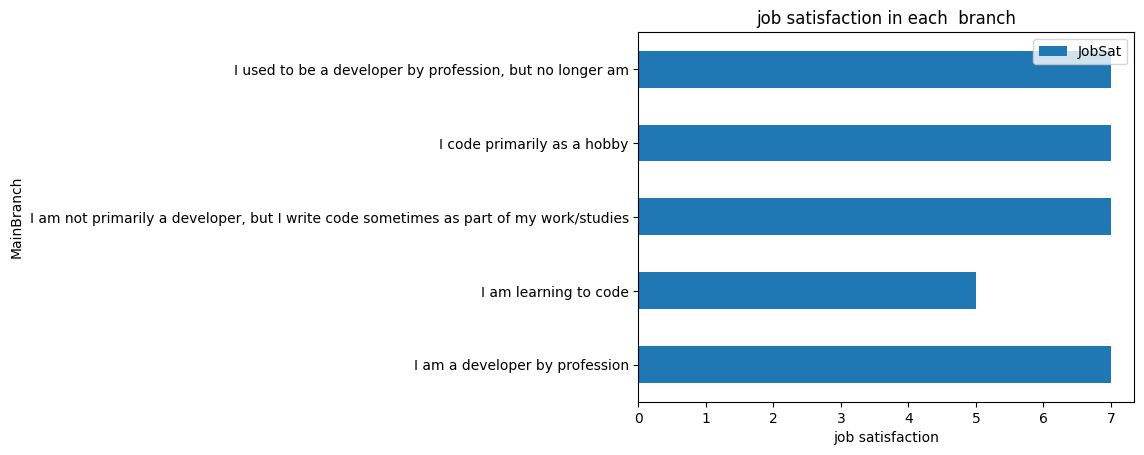

In [26]:
median_sat.plot(
                kind='barh'
                ,title='job satisfaction in each  branch'
                ,xlabel='job satisfaction')
plt.show()

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [27]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
